# DECI project : `Ford gobike` 

## *exploratory data analysis*

The Ford GoBike System Data contains information about a bike-sharing service that was available in the San Francisco Bay Area. It includes details about bike trips, such as where and when they started and ended, how long they lasted, and the type of users who rode them. This data can help people understand how bike-sharing is used in the city, including travel patterns and popular routes.

## Table of Contents

 - Gathering the Data
 - Cleaning the Data
 - Univariate Exploration
 - Bivariate Exploration
 - Multivariate Exploration

importing needed libararies

In [2]:
import pandas as pd              # for data manipulation
import numpy as np               # for numerical computation
import matplotlib.pyplot as plt  # for data visualization
import seaborn as sns            # for data visualization

## Data gatering

In [3]:
df = pd.read_csv('201902-fordgobike-tripdata.csv') # loading the data

### Assessing data

In [4]:
df.head() # to check the first 5 rows of the data

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [5]:
df.info() # to get a concise summary of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [6]:
df.describe() # summary statistics

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [7]:
df.isna().sum() # checking for missing values

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [8]:
df.duplicated().sum() # checking for duplicates

0

#### *Assesment Report* 

1. there are unnecessary column such as start_station_id, start_station_latitude, start_station_longitude ,end_station_id, end_station_latitude and end_station_longitude

2. data type of the columns 'start_time' and 'end_time' should be  datetime

3. nan values of gender column should be replaced by other

4. add 'year-month' column for better analysis 

5. there is nan values in 'memeber_birth_year' 

6. add 'age' column and 'age_group' column for better analysis


## Data cleaning

In [9]:
df_clean = df.copy()  # making a copy of the data
df_clean.head()       # to check the first 5 rows of the data

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


getting rid of unnecessary columns

In [10]:
columns_to_drop = ['start_station_id', 'start_station_latitude', 'start_station_longitude',
                   'end_station_id', 'end_station_latitude', 'end_station_longitude','start_station_name', 'end_station_name', 'bike_id'] # columns that will be removed
df_clean.drop(columns = columns_to_drop, inplace = True) # dropping the columns
df_clean.head(1) # checking the first row of the data

,duration_sec,start_time,end_time,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,Customer,1984.0,Male,No


changing the data type of the start_time and end_time to datetime

In [11]:
df_clean['start_time'] = pd.to_datetime(df_clean['start_time']) # changing the data type of the start_time and end_time to datetime
df_clean['end_time'] = pd.to_datetime(df_clean['end_time'])     # changing the data type of the start_time and end_time to datetime
df_clean.info()                                                 # checking the data type of the columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             183412 non-null  int64         
 1   start_time               183412 non-null  datetime64[ns]
 2   end_time                 183412 non-null  datetime64[ns]
 3   user_type                183412 non-null  object        
 4   member_birth_year        175147 non-null  float64       
 5   member_gender            175147 non-null  object        
 6   bike_share_for_all_trip  183412 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(3)
memory usage: 9.8+ MB


filling nan values in gender column

In [12]:
df_clean['member_gender'].replace(np.nan, 'Other', inplace=True)  # replacing the missing values in the
df_clean['member_gender'].value_counts()                          # checking the values in the member

C:\Users\Kimo Store\AppData\Local\Temp\ipykernel_5188\3079506083.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['member_gender'].replace(np.nan, 'Other', inplace=True)  # replacing the missing values in the


member_gender
Male      130651
Female     40844
Other      11917
Name: count, dtype: int64

adding 'year-month' column for better analysis

In [13]:
df_clean['year-month'] = df_clean['start_time'].dt.to_period('M')   # creating a new column for the year and month
df_clean['year-month'].head()                                       # checking the new column

0    2019-02
1    2019-02
2    2019-02
3    2019-02
4    2019-02
Name: year-month, dtype: period[M]

replacing nan values in 'member_birth_year' with the mean 

In [14]:
df_clean['member_birth_year'] = pd.to_numeric(df_clean['member_birth_year'], errors='coerce')  # changing the data type of the member_birth_year to numeric
mean_birth_year = df_clean['member_birth_year'].mean()                                         # getting the mean of the member_birth_year
df_clean['member_birth_year'].fillna(mean_birth_year, inplace=True)                            # filling the missing values with the mean

C:\Users\Kimo Store\AppData\Local\Temp\ipykernel_5188\2573722534.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['member_birth_year'].fillna(mean_birth_year, inplace=True)                            # filling the missing values with the mean


adding 'age' and 'age_group' for better analysis

In [15]:
df_clean['age'] = 2019 - df_clean['member_birth_year'] # creating a new column for the age

In [16]:
age_bins = [0, 19, 29, 39, 49, 59,
            69, 79, 89, 99] # creating bins for the age
age_labels = ['10 - 19', '20 - 29', '30 - 39', '40 - 49', '50 - 59',
              '60 - 69', '70 - 79', '80 - 89', '90 - 99'] # creating labels for the age

df_clean['age_group'] = pd.cut(df_clean['age'], bins = age_bins, labels = age_labels, right = False) # creating a new column for the age group

In [17]:
df_clean[['age', 'age_group']].head() # checking the new columns

,age,age_group
0,35.000000,30 - 39
1,34.193563,30 - 39
2,47.000000,40 - 49
3,30.000000,30 - 39
4,45.000000,40 - 49


saving df_clean in df

In [18]:
df_clean.to_csv('fordgobike-tripdata-clean.csv', index = False) # saving the cleaned data
df= pd.read_csv('fordgobike-tripdata-clean.csv') # loading the cleaned data

#### now all the cleaning is done!

## Univariate Exploration

In [19]:
def plot_univariate(df, col, plot_type='hist', title='', xlabel='', ylabel='', log_scale=False, bins=None):
    """ 
    Function to generate univariate plots (histogram or bar chart).
    
    Parameters:
        df (DataFrame): The dataset containing the column to plot.
        col (str): The column to visualize.
        plot_type (str): Type of plot ('hist' for histogram, 'bar' for bar chart).
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        log_scale (bool): Whether to use a log scale on the y-axis.
        bins (array-like, optional): Custom bin edges for histograms.
    """
    plt.figure(figsize=(10, 5))

    if plot_type == 'hist':
        plt.hist(df[col], bins=bins, edgecolor='black') if bins is not None else plt.hist(df[col], edgecolor='black')
    elif plot_type == 'bar':
        df[col].value_counts().sort_index().plot(kind='bar', edgecolor='black')
    else:
        raise ValueError("Invalid plot_type. Use 'hist' or 'bar'.")

    if log_scale:
        plt.yscale('log')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


### What is the distribution of trip durations in the Ford GoBike dataset?

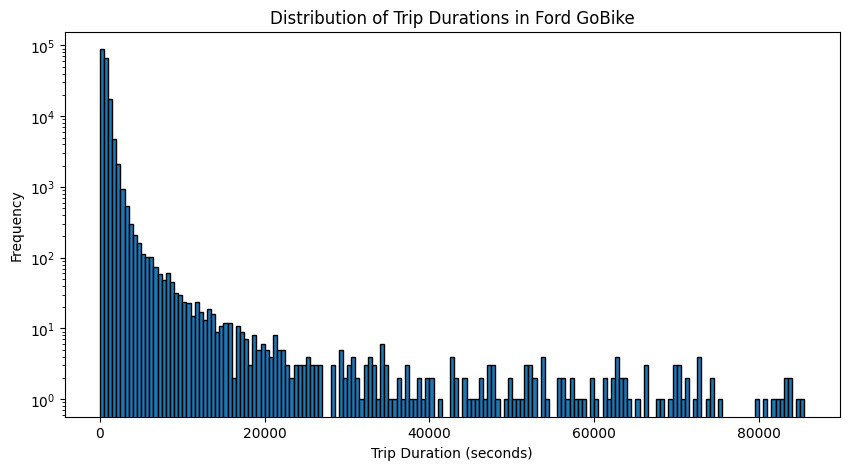

In [20]:
# histogram 
# Define custom bins for the histogram
bins = np.arange(0, df['duration_sec'].max() + 500, 500)
plot_univariate(df, col='duration_sec', plot_type='hist', bins=bins, log_scale=True,
                title='Distribution of Trip Durations in Ford GoBike',
                xlabel='Trip Duration (seconds)', ylabel='Frequency')

In this analysis, we look at the distribution of trip durations in the Ford GoBike dataset using a histogram. Since the data is heavily right-skewed due to extremely long trips, we apply a logarithmic scale on the y-axis to better visualize the data. Even with this adjustment, we see that most trips are fairly short, with the majority lasting under 1,000 seconds (~16 minutes). However, there are some very long trips (over 80,000 seconds or ~22 hours), which may suggest outliers, system errors, or potential misuse. This indicates that most users take quick rides, but further analysis is needed to investigate outliers and usage patterns across different rider types

### What age group uses bikes the most?

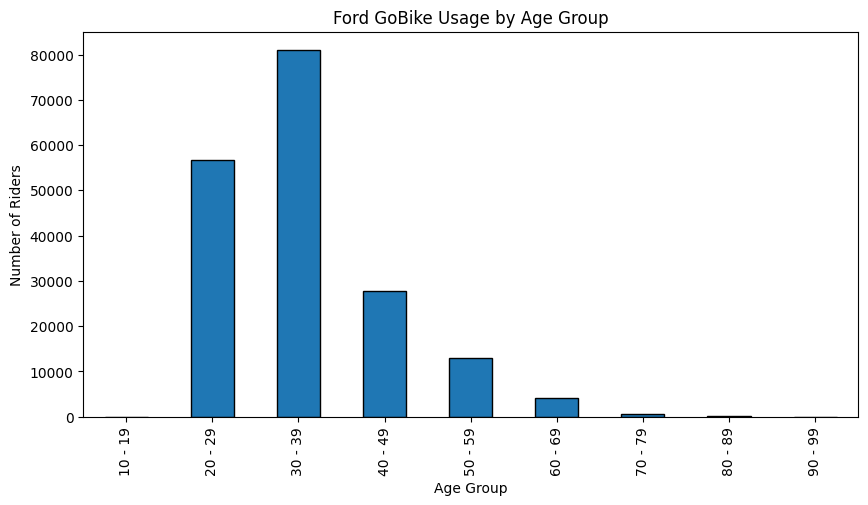

In [21]:
# bar chart
plot_univariate(df, col='age_group', plot_type='bar',
                title='Ford GoBike Usage by Age Group',
                xlabel='Age Group', ylabel='Number of Riders')

In this analysis, we examine bike usage across different age groups to identify which group rides the most. The bar chart shows that the 20-39 age range dominates bike usage, with the 30-39 age group having the highest number of riders, followed closely by 20-29-year-olds. After age 40, there is a gradual decline in usage, with significantly fewer riders in the 50+ age range. The drop-off is sharp after 60, suggesting that bike-sharing is primarily popular among young and middle-aged adults, likely due to commuting and convenience. 

## Bivariate Exploration

In [22]:
def plot_bivariate(df, x_col, y_col=None, plot_type='scatter', title='', xlabel='', ylabel='', log_scale=False, hue=None, filter_y=None):
    """ 
    Function to generate bivariate plots (scatter, boxplot, or bar).
    
    Parameters:
        df (DataFrame): The dataset containing the columns to plot.
        x_col (str): The column for the x-axis.
        y_col (str, optional): The column for the y-axis (required for scatter and boxplot).
        plot_type (str): Type of plot ('scatter', 'box', 'bar').
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        log_scale (bool): Whether to use a log scale on the y-axis.
        hue (str, optional): Column for color grouping in bar plots.
        filter_y (float, optional): Upper limit to filter y_col values.
    """
    plt.figure(figsize=(10, 5))

    if filter_y and y_col:
        df = df[df[y_col] <= filter_y]

    if plot_type == 'scatter':
        sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.5)
    elif plot_type == 'box':
        sns.boxplot(data=df, x=x_col, y=y_col)
    elif plot_type == 'bar':
        sns.countplot(data=df, x=x_col, hue=hue)
    else:
        raise ValueError("Invalid plot_type. Use 'scatter', 'box', or 'bar'.")

    if log_scale:
        plt.yscale('log')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


### How does trip duration vary with age?

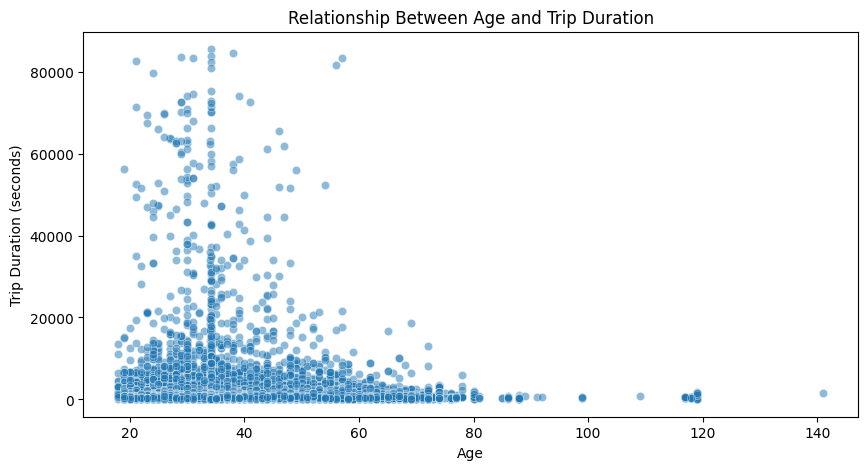

In [23]:
# Scatter plot
plot_bivariate(df, x_col='age', y_col='duration_sec', plot_type='scatter',
               title='Relationship Between Age and Trip Duration',
               xlabel='Age', ylabel='Trip Duration (seconds)')

In this analysis, we explore the relationship between age and trip duration to see if certain age groups tend to take longer rides. The scatter plot shows that most trips are short, clustering under 5,000 seconds (~83 minutes). However, younger riders, particularly those in their 20s and 30s, have a higher likelihood of taking longer trips, with some exceeding 20,000 seconds (~5.5 hours). As age increases, trip durations become shorter and more consistent, suggesting that older riders prefer quicker trips.

We also notice some outliers, especially users with ages over 100, which likely result from incorrect birth year entries. Cleaning the data to remove unrealistic ages and filtering extreme trip durations could help improve accuracy. Overall, this plot suggests that younger riders are more frequent and take longer trips, while older riders tend to keep their rides short.

###

### How does trip duration vary between different user types (Subscribers vs. Customers)?

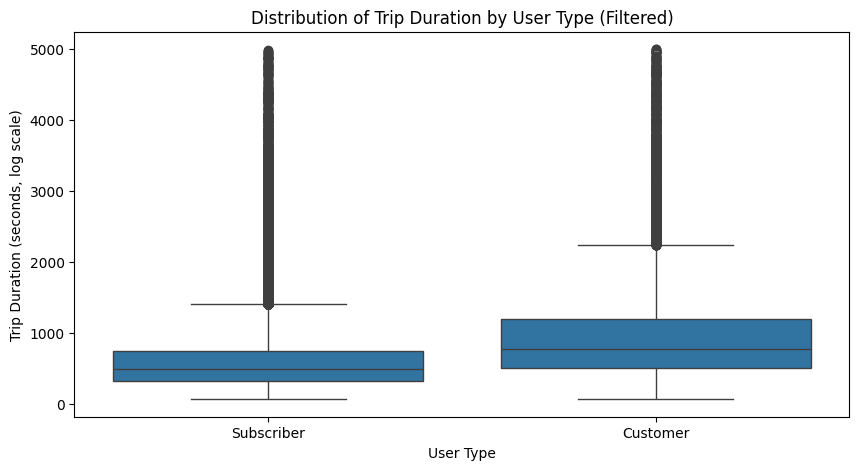

In [24]:
# Box plot
plot_bivariate(df, x_col='user_type', y_col='duration_sec', plot_type='box',
               title='Distribution of Trip Duration by User Type (Filtered)',
               xlabel='User Type', ylabel='Trip Duration (seconds, log scale)',
               filter_y=5000)

This visualization shows that Subscribers tend to take shorter and more consistent trips, likely for commuting, while Customers take longer trips with more variation, possibly for leisure or occasional use. Understanding this difference can help in optimizing pricing and marketing strategies for both user groups.

###

### How does bike usage vary between different user types (Subscriber vs Customer) across age groups?

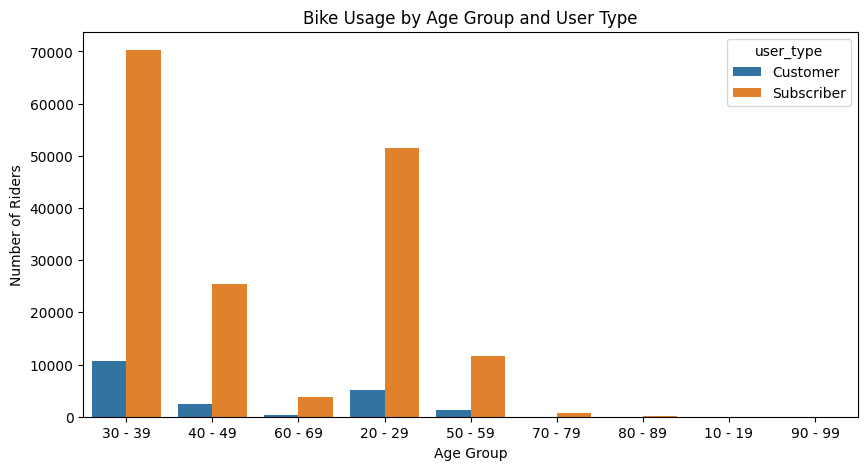

In [25]:
# clustered bar chart
plot_bivariate(df, x_col='age_group', plot_type='bar', hue='user_type',
               title='Bike Usage by Age Group and User Type',
               xlabel='Age Group', ylabel='Number of Riders')

From this clustered bar chart, we can see how bike usage varies by age group and user type. The 30-39 age group has the highest number of riders, followed by 20-29. Across all age groups, subscribers significantly outnumber customers, suggesting that most riders prefer a membership-based system rather than occasional rentals. The difference is especially noticeable in younger age groups, where subscribers dominate. As age increases, the overall number of riders decreases, indicating that bike-sharing is more popular among younger adults. 

## Multivariate Exploration

### Do trip duration patterns differ by user type and day of the week?

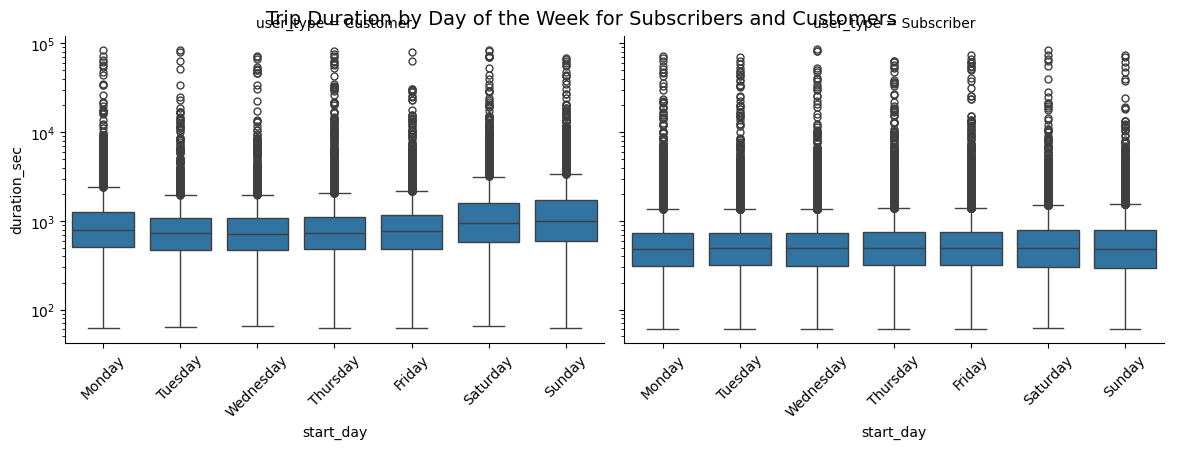

In [26]:
# FacetGrid with a box plot
# Convert start_time to day of the week if not already
df['start_day'] = pd.to_datetime(df['start_time']).dt.day_name()

# Create a FacetGrid with a box plot
g = sns.catplot(
    data=df,
    x="start_day",
    y="duration_sec",
    col="user_type",
    kind="box",
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    height=4, aspect=1.5
)

# Apply log scale
g.set(yscale="log")

# Rotate x-axis labels for better readability
g.set_xticklabels(rotation=45)

# Set a main title
g.fig.suptitle("Trip Duration by Day of the Week for Subscribers and Customers", fontsize=14)

# Show the plot
plt.show()


From this faceted box plot, we can see how trip duration varies by day of the week for both customer and subscriber users. Customers generally have longer trip durations compared to subscribers, as shown by the higher median and wider spread of the box plots. This suggests that customers may use the service for leisure or infrequent trips, whereas subscribers tend to take shorter, more consistent trips, likely for commuting. Trip durations remain fairly consistent across all days of the week for both user types, indicating that weekday and weekend usage patterns are similar.

### How do age, trip duration, and user type interact in the dataset? Are there noticeable trends based on user type?

In [27]:
# scatter plot with multiple incodings
# Filter out unrealistic ages (e.g., age > 100)
filtered_df = df[df['age'] <= 100]

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a scatter plot with improved readability
sns.scatterplot(data=filtered_df, x='age', y='duration_sec', hue='user_type', alpha=0.3, s=10)

# Set logarithmic scale for better visibility
plt.yscale('log')

# Set labels and title
plt.xlabel('Age')
plt.ylabel('Trip Duration (seconds, log scale)')
plt.title('Relationship Between Age, Trip Duration, and User Type')

# Display the plot
plt.show()


KeyboardInterrupt: 

From this scatter plot, we can observe the relationship between age, trip duration, and user type. Most trips are taken by users aged 20 to 40, with a noticeable decline in ridership as age increases. Across all age groups, subscribers outnumber customers, reinforcing the trend that most riders prefer a membership-based system.

Trip duration varies significantly, but most rides are concentrated within shorter durations, with a few outliers showing extremely long trips. Older riders (60+) participate less frequently, and their trips tend to be shorter in duration. The dense cluster at the bottom of the plot highlights that short-duration trips are the norm for all age groups, but customers appear to have slightly more variation in their trip times.

# 🎉The data exploration is done !🎉